<a href="https://colab.research.google.com/github/Rut092/AI-Journey-Practice/blob/main/Article5(Imbalanced_dataset_AUC_ROC_RECALL_Threshold).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the Libraries

In [38]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve,classification_report
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Generating and Splitting Imnbalanced Data

In [4]:
X,y = make_classification(
    n_samples = 100000,
    n_features= 20,
    weights=[0.99,0.1],
    random_state=42
                          )
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
# stratify y is important for imbalanced dataset to split even

## Training Evaluation Model with Balanced Weights

In [6]:
eval_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced', # Automatically adjusts weights inversely proportional to class frequencies to handle imbalanced datasets.
    n_jobs=-1, # Uses all available CPU cores for parallel processing, speeding up computation.
    max_depth=10
)
eval_model.fit(X_train,y_train)
y_pred = eval_model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     28360
           1       0.49      0.80      0.61      1640

    accuracy                           0.94     30000
   macro avg       0.74      0.87      0.79     30000
weighted avg       0.96      0.94      0.95     30000



The classification report provides a detailed view of your model's performance, especially crucial for imbalanced datasets:

*   **Support:** This shows the number of actual occurrences of each class in the test set. Here, `class 0` is the majority class (28,360 samples) and `class 1` is the minority class (1,640 samples), confirming the dataset's imbalance.

*   **Accuracy (0.94):** While a high accuracy of 94% looks good, it can be misleading in imbalanced datasets. The model could achieve high accuracy by simply predicting the majority class most of the time. For example, if it always predicted class 0, it would still be correct 94% of the time, but would miss all of class 1.

*   **Class 0 (Majority Class):**
    *   **Precision (0.99):** When the model predicts an instance belongs to class 0, it is correct 99% of the time. This is excellent.
    *   **Recall (0.95):** The model correctly identifies 95% of all actual class 0 instances. This is also very good.
    *   **F1-score (0.97):** The F1-score, a harmonic mean of precision and recall, is high, indicating strong performance for the majority class.

*   **Class 1 (Minority Class):**
    *   **Precision (0.49):** When the model predicts an instance belongs to class 1, it is only correct 49% of the time. This is relatively low, meaning that nearly half of the predictions for class 1 are actually incorrect (False Positives). The model is flagging many instances as class 1 that are actually class 0.
    *   **Recall (0.80):** The model correctly identifies 80% of all actual class 1 instances. This is a decent recall score, especially considering the class imbalance. It suggests the model is fairly good at 'catching' the positive cases.
    *   **F1-score (0.61):** This score is moderate. It's a balance between the low precision and good recall for class 1. It suggests that while the model is good at finding positive instances (recall), it often misclassifies negative instances as positive (low precision).

**In summary:**
model performs exceptionally well on the **majority class (class 0)**. However, for the **minority class (class 1)**, while it has a good ability to identify actual positive cases (high recall), it struggles with precision. This means it often incorrectly flags negative cases as positive, leading to a moderate overall F1-score for the minority class. This is a common trade-off when dealing with imbalanced datasets, even with `class_weight='balanced'` which typically helps improve recall for the minority class.

In [12]:
y_probs = eval_model.predict_proba(X_test)
print("  class 0      class 1")
print(y_probs)

  class 0      class 1
[[0.88426786 0.11573214]
 [0.94463732 0.05536268]
 [0.93076879 0.06923121]
 ...
 [0.85612199 0.14387801]
 [0.5109411  0.4890589 ]
 [0.91068884 0.08931116]]


## Optimizing decision boundary threshold

In [13]:
y_probs_class1 = y_probs[:,1]
precision,recall,threshold = precision_recall_curve(y_test,y_probs_class1)
f1_scores = 2*precision*recall/(precision+recall+1e-10)
print(f1_scores)

[0.10366625 0.10366952 0.1036728  ... 0.00243605 0.00121877 0.        ]


In [14]:
# Find the index of the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = threshold[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best F1 Score for Class 1: {best_f1:.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")

# NOTE: We pick the best F1 score for Class 1 because in imbalanced tasks
# (like fraud detection), we want to balance catching as many positive cases
# as possible (Recall) without flagging too many false alarms (Precision).
# Adjusting the threshold allows us to find the 'sweet spot' for the minority class.

Best F1 Score for Class 1: 0.7574
Optimal Threshold: 0.8407


## Retraining the 100% of the data

In [15]:
final_production_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
final_production_model.fit(X,y)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [17]:
artifacts = {'model':final_production_model,'threshold':best_threshold}
joblib.dump(artifacts,'artifacts.joblib')

['artifacts.joblib']

In [18]:
deployed_pipeline = joblib.load('artifacts.joblib')
deployed_model = deployed_pipeline['model']
deployed_threshold = deployed_pipeline['threshold']

In [20]:
# 1. Create a sample dataset (e.g., 5 new samples with 20 features)
sample_data = np.random.randn(5, 20)

# 2. Get probabilities from the deployed model
# [:, 1] selects the probability of the positive class (Class 1)
sample_probs = deployed_model.predict_proba(sample_data)[:, 1]

# 3. Apply the optimal threshold to get final binary predictions
# If probability > threshold, classify as 1, else 0
final_predictions = (sample_probs >= deployed_threshold).astype(int)

print("Probabilities for Class 1:", sample_probs)
print("Final Predictions using Threshold:", final_predictions)

Probabilities for Class 1: [0.33146387 0.9847688  0.19857    0.18217468 0.44647851]
Final Predictions using Threshold: [0 1 0 0 0]


## MultiClass Imbalanced Data

In [22]:
X_multi,y_multi = make_classification(
    n_samples=100000,
    n_features=20,
    n_classes=3,
    n_clusters_per_class=1, # Each class is composed of one group/cluster of points;
                            # higher values make the classification task more complex
    weights=[0.85,0.12,0.03],
    random_state=42
)

In [23]:
X_train_multi,X_test_multi,y_train_multi,y_test_multi = train_test_split(X_multi,y_multi,test_size=0.3,stratify=y_multi,random_state=42)

In [24]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    max_depth=10
)
model.fit(X_train_multi,y_train_multi)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [25]:
y_probs_multi = model.predict_proba(X_test_multi)
y_pred_multi = model.predict(X_test_multi)
print(classification_report(y_test_multi,y_pred_multi))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     25342
           1       0.98      0.94      0.96      3667
           2       0.98      0.82      0.89       991

    accuracy                           0.99     30000
   macro avg       0.98      0.92      0.95     30000
weighted avg       0.99      0.99      0.99     30000



In [28]:
print(y_probs_multi)

[[0.8535626  0.01729397 0.12914343]
 [0.87260373 0.04611049 0.08128579]
 [0.86385554 0.04084824 0.09529621]
 ...
 [0.88010813 0.05021215 0.06967972]
 [0.84747699 0.03976481 0.1127582 ]
 [0.84244142 0.10984838 0.0477102 ]]


In [26]:
default_preds = np.argmax(y_probs_multi,axis=1)
print(default_preds)

[0 0 0 ... 0 0 0]


In [27]:
print(np.unique(default_preds, return_counts=True))

(array([0, 1, 2]), array([25670,  3502,   828]))


In [32]:
class_multiplier = np.array([1.0, 2.5, 6.0])
# We multiply probabilities to 'bias' the model towards minority classes.
# 6.0 for 'Attack' means we care 6x more about catching it than 'Normal'.
weighted_probs = y_probs_multi * class_multiplier

# argmax now picks the class with the highest *weighted* probability.
weighted_preds = np.argmax(weighted_probs, axis=1)

# NOTE: This increases Recall (catches more attacks) but decreases Precision
# (causes more false alarms). It is a strategic choice based on business cost.
print(weighted_preds)

[0 0 0 ... 0 0 0]


In [33]:
print(np.unique(weighted_preds, return_counts=True))

(array([0, 1, 2]), array([24350,  3553,  2097]))


In [34]:
print(classification_report(
    y_test_multi,weighted_preds,
    target_names=['Normal','Glitch','Attack']
    ))

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     25342
      Glitch       0.98      0.95      0.97      3667
      Attack       0.41      0.87      0.56       991

    accuracy                           0.95     30000
   macro avg       0.80      0.93      0.83     30000
weighted avg       0.97      0.95      0.96     30000



## Standard Template to find wheather Classification has Imbalanced Data


--- Running Test A ---
0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Length: 50000, dtype: int64 y_series-values
0    49506
1      494
Name: count, dtype: int64 counts_seies
0    0.99012
1    0.00988
Name: proportion, dtype: float64 percentages_of_series
          DATASET IMBALANCE DIAGNOSTIC            
   Total Rows Percentage
0       49506     99.01%
1         494      0.99%
--------------------------------------------------
Status: 🚨 SEVERE IMBALANCE DETECTED
Majority-to-Minority Ratio: 100.21:1
Engineering Action Required: CRITICAL: You MUST use stratify=y, class_weight='balanced', evaluate via PR-AUC, and apply custom threshold tuning.


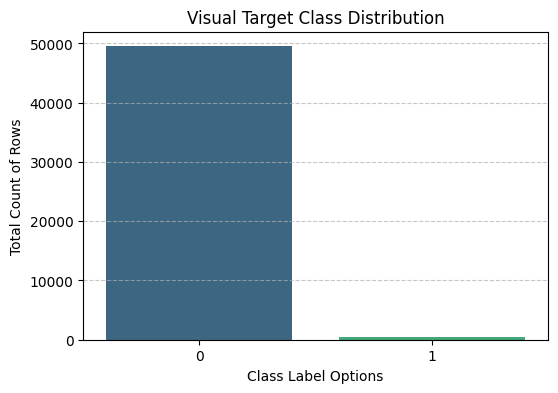


--- Running Test B ---
0       Bird
1       Bird
2        Dog
3        Dog
4        Cat
        ... 
9995     Dog
9996     Dog
9997     Dog
9998     Cat
9999     Dog
Length: 10000, dtype: object y_series-values
Dog     3421
Bird    3290
Cat     3289
Name: count, dtype: int64 counts_seies
Dog     0.3421
Bird    0.3290
Cat     0.3289
Name: proportion, dtype: float64 percentages_of_series
          DATASET IMBALANCE DIAGNOSTIC            
      Total Rows Percentage
Dog         3421     34.21%
Bird        3290     32.90%
Cat         3289     32.89%
--------------------------------------------------
Status: ✅ DATASET IS BALANCED
Majority-to-Minority Ratio: 1.04:1
Engineering Action Required: SAFE: Classes are evenly distributed. Standard accuracy metrics and model defaults will work fine.


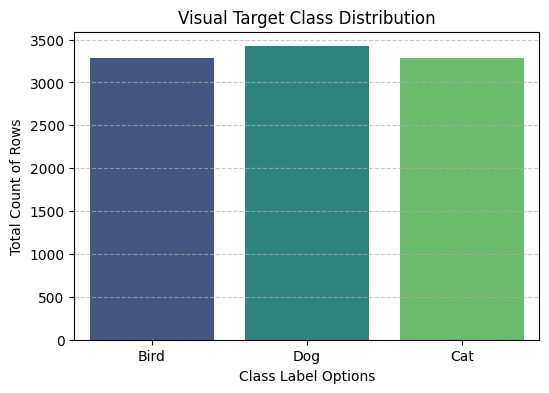

In [42]:
def detect_imbalance(y, threshold_severe=0.05, threshold_moderate=0.20):

    # 1. Convert to a pandas Series if it isn't one already
    y_series = pd.Series(y)
    print(y_series,'y_series-values')


    # 2. Calculate raw counts and percentage representations
    counts = y_series.value_counts()
    print(counts,'counts_seies')

    percentages = y_series.value_counts(normalize=True)
    print(percentages,'percentages_of_series')

    # 3. Build a clean diagnostic dashboard table
    diagnostic_df = pd.DataFrame({
        'Total Rows': counts,
        'Percentage': percentages
    })

    print("==================================================")
    print("          DATASET IMBALANCE DIAGNOSTIC            ")
    print("==================================================")
    # Format the table display nicely
    print(diagnostic_df.to_string(formatters={'Percentage': '{:,.2%}'.format}))
    print("--------------------------------------------------")

    # 4. Pull out tracking metrics
    min_class_pct = percentages.min()
    max_class_counts = counts.max()
    min_class_counts = counts.min()
    imbalance_ratio = max_class_counts / min_class_counts

    # 5. Determine the severity status using industry standards
    if min_class_pct <= threshold_severe:
        status = "🚨 SEVERE IMBALANCE DETECTED"
        advice = "CRITICAL: You MUST use stratify=y, class_weight='balanced', evaluate via PR-AUC, and apply custom threshold tuning."
    elif min_class_pct <= threshold_moderate:
        status = "⚠️ MODERATE IMBALANCE DETECTED"
        advice = "WARNING: Stratify your train/test splits. Use F1-Score instead of raw accuracy to grade performance."
    else:
        status = "✅ DATASET IS BALANCED"
        advice = "SAFE: Classes are evenly distributed. Standard accuracy metrics and model defaults will work fine."

    print(f"Status: {status}")
    print(f"Majority-to-Minority Ratio: {imbalance_ratio:.2f}:1")
    print(f"Engineering Action Required: {advice}")
    print("==================================================")

    # 6. Visual verification using our universal formula: sns.plot(data, x)
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_series, hue=y_series, legend=False, palette="blueprint" if 'blueprint' in plt.colormaps else "viridis")
    plt.title("Visual Target Class Distribution")
    plt.xlabel("Class Label Options")
    plt.ylabel("Total Count of Rows")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# =====================================================================
# SIMULATION AREA: Testing our function on different datasets
# =====================================================================

# Scenario A: Simulating a 1% rare fraud/attack dataset
print("\n--- Running Test A ---")
y_rare = np.random.choice([0, 1], size=50000, p=[0.99, 0.01])
detect_imbalance(y_rare)

# Scenario B: Simulating a normal, balanced dataset
print("\n--- Running Test B ---")
y_balanced = np.random.choice(["Cat", "Dog", "Bird"], size=10000, p=[0.34, 0.33, 0.33])
detect_imbalance(y_balanced)